<a href="https://colab.research.google.com/github/zamanuddinkhan/Python-AI-LLM/blob/main/CrewAI_Explorer_Assistant_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **AI-Driven Explorer Assistant using CrewAI multi-agent Collaboration**

Goal:
Build a multi-agent AI Explorer Assistant that can take a topic (e.g., “Ethical AI Agents”), search the web for Webpages or summaries, synthesize the content into a structured report, and finally review and refine it for clarity.

**System Architecture**

**Agents**

- Explorer Agent – searches the web and collects information.

- Writer Agent – summarizes and organizes information into a report.

- Reviewer Agent – proofreads, checks consistency, and improves style.

**Process Layer**

- Sequential workflow: Research → Write → Review.

- Data flows through shared memory (contextual handoff).

**Tools**

- WebSearchTool(Serper API) – retrieves information from the web.

- SummarizerTool – condenses long text.


**Output**

A structured text summary/report (printed or saved as .txt or .md).

**Tasks**

- Take any topic

- Search the web

- Summarize findings

- Review & refine the report

- Present the final polished result

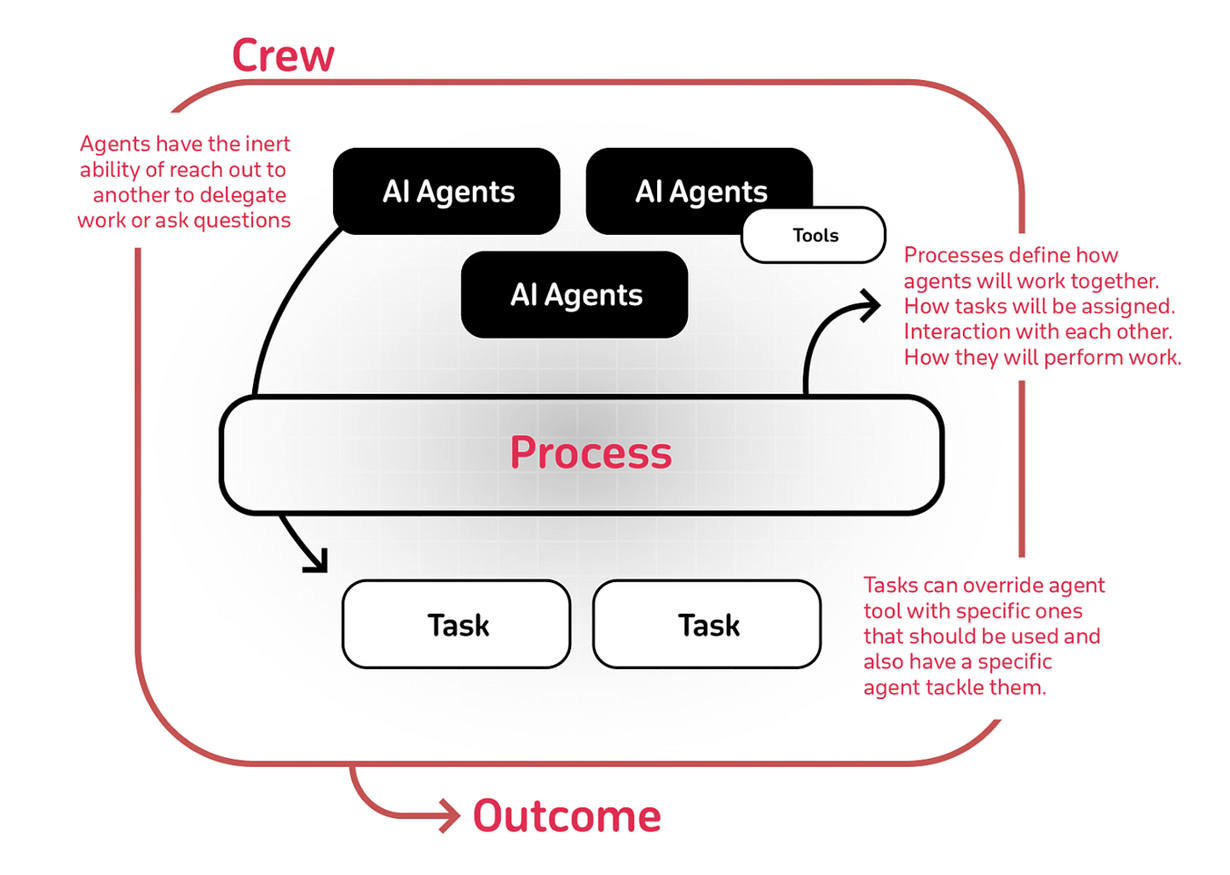

In [ ]:
pip install crewai crewai-tools langchain openai langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 9.1 MB/s eta 0:00:00


## Setup keys

In [ ]:
import os
from google.colab import userdata

openai_key = userdata.get('OPENAI_API_KEY')
serper_key = userdata.get('SERPER_API_KEY')

if openai_key:
    os.environ['OPENAI_API_KEY'] = openai_key
    print("OPENAI_API_KEY loaded successfully.")
else:
    print("OPENAI_API_KEY not found in userdata. Please set it in Colab secrets.")

if serper_key:
    os.environ['SERPER_API_KEY'] = serper_key
    print("SERPER_API_KEY loaded successfully.")
else:
    print("SERPER_API_KEY not found in userdata. Please set it in Colab secrets.")

OPENAI_API_KEY loaded successfully.
SERPER_API_KEY loaded successfully.


## Define Agents

In [ ]:
from crewai import Agent
from crewai_tools import SerperDevTool
from langchain_openai import ChatOpenAI
import os

# Initialize the LLM with the API key
llm = ChatOpenAI(model="gpt-4o", openai_api_key=os.environ.get('OPENAI_API_KEY'))

# Initialize search tool only if SERPER_API_KEY is available
search_tool = None
if 'SERPER_API_KEY' in os.environ and os.environ['SERPER_API_KEY']:
    search_tool = SerperDevTool()
    print("SerperDevTool initialized successfully.")
else:
    print("SERPER_API_KEY not set. Search tool will not be available.")

explorer = Agent(
    role="Explorer",
    goal="Gather recent and relevant information on a given topic.",
    backstory="Expert at finding concise, factual, and up-to-date online data.",
    tools=[search_tool] if search_tool else [], # Only add tool if initialized
    llm=llm # Explicitly pass the LLM
)

writer = Agent(
    role="Writer",
    goal="Summarize findings and structure them into a readable report.",
    backstory="A skilled writer with academic and analytical writing style.",
    llm=llm # Explicitly pass the LLM
)

reviewer = Agent(
    role="Reviewer",
    goal="Proofread and refine the report for clarity and professionalism.",
    backstory="Experienced editor focusing on accuracy and coherence.",
    llm=llm # Explicitly pass the LLM
)

SerperDevTool initialized successfully.


ValidationError: 2 validation errors for Agent
llm.str
  Input should be a valid string [type=string_type, input_value=ChatOpenAI(profile={'name...eam_chunk_timeout=120.0), input_type=ChatOpenAI]
    For further information visit https://errors.pydantic.dev/2.12/v/string_type
llm.BaseLLM
  Input should be a valid dictionary or instance of BaseLLM [type=model_type, input_value=ChatOpenAI(profile={'name...eam_chunk_timeout=120.0), input_type=ChatOpenAI]
    For further information visit https://errors.pydantic.dev/2.12/v/model_type

## Define Tasks

In [ ]:
query=input("Enter topic to Explore:")

Enter topic to Explore:Oil production in Iran


## Define Query

In [ ]:
from crewai import Task

task1 = Task(
    description=query,
    agent=explorer,
    expected_output=f"A comprehensive summary of recent developments and key insights on {query}, including relevant webpages found."
)

task2 = Task(
    description=f"Create a 500-word report summarizing and structuring the explored webpage data.",
    agent=writer,
    expected_output=f"A 500-word structured report based on the explored data, summarizing the key findings on {query}"
)

task3 = Task(
    description="Review and edit the report for grammar, tone, and readability.",
    agent=reviewer,
    expected_output=f"A polished, error-free, and clear 500-word report on {query}, ready for publication, with improved grammar, tone, and readability."
)

## Build the Crew and Process

In [ ]:
from crewai import Crew

crew = Crew(
    agents=[explorer, writer, reviewer],
    tasks=[task1, task2, task3],
    process="sequential",  # or "hierarchical"/"parallel"
    verbose=True
)

result = crew.kickoff()
print(result)

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 0cb47cc9-966c-4e7d-b5de-0c09ccdca714                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Oil production in Iran                                                                                   │
│  ID: 27506fba-89e8-424c-9686-c055d3dcc155                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Failure ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Failed                                                                                                    │
│  Name: Oil production in Iran                                                                                   │
│  Agent: Explorer                                                                                                │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────── Crew Failure ──────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Failed                                                                                          │
│  Name: crew                                                                                                     │
│  ID: 0cb47cc9-966c-4e7d-b5de-0c09ccdca714                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

RuntimeError: Agent execution was invoked synchronously from within a running event loop. Use `agent.kickoff_async()` / `crew.kickoff_async()` (or `await agent.aexecute_task(...)`) when calling from async code.



╭────────────────────────── Tracing Preference Saved ──────────────────────────╮
│                                                                              │
│  Info: Tracing has been disabled.                                            │
│                                                                              │
│  Your preference has been saved. Future Crew/Flow executions will not        │
│  collect traces.                                                             │
│                                                                              │
│  To enable tracing later, do any one of these:                               │
│  • Set tracing=True in your Crew/Flow code                                   │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file               │
│  • Run: crewai traces enable                                                 │
│                                                                              │
╰─────────────────────────

In [ ]:
from IPython.display import Markdown
Markdown(result.raw)